In [34]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


if GPU is available use that, otherwise use cpu.

In [35]:
def generate_data(num_samples=2048, seq_len=32, d_model=64):
    X = torch.randn(num_samples, seq_len, d_model)
    y = X.mean(dim=1)
    return X, y


Create test data for sampling. This generated data set is consistent for testing and helps to make outcomes deterministic. 

In [36]:
class AttentionModel(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            batch_first=True
        )
        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        pooled = attn_out.mean(dim=1)
        return self.fc(pooled)


Creation of the neural network module with self.attn creating multi-head self-attention. self.fc makes it so the model doesn't only use attention. forward makes use of queries, keys, and values.

In [37]:
def train_and_profile(
    num_heads,
    X,
    y,
    epochs=10,
    runs=3
):
    forward_times = []
    total_times = []
    peak_memories = []
    loss_curves = []

    for run in range(runs):
        model = AttentionModel(X.shape[-1], num_heads).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss()

        Xd, yd = X.to(device), y.to(device)

        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()

        run_losses = []
        run_times = []

        start_train = time.time()

        for _ in range(epochs):
            # --- Forward timing ---
            start_fwd = time.time()
            preds = model(Xd)
            torch.cuda.synchronize() if device.type == "cuda" else None
            forward_times.append(time.time() - start_fwd)

            loss = criterion(preds, yd)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            run_losses.append(loss.item())
            run_times.append(time.time() - start_train)

        total_times.append(time.time() - start_train)
        loss_curves.append((run_times, run_losses))

        if device.type == "cuda":
            peak_memories.append(
                torch.cuda.max_memory_allocated() / 1024**2
            )

    return {
        "mean_forward_time": np.mean(forward_times),
        "mean_total_time": np.mean(total_times),
        "mean_peak_memory": np.mean(peak_memories) if peak_memories else None,
        "loss_curves": loss_curves
    }


first four arrays, forward_times; total_times; etc..., collects metrics for the different number of heads used to process data.

Do multiple runs of testing to reduce noise and makes data gathered from testing more accurate.

Create a fresh model per run.

If gpu is being used make sure to clear the previous memory statistics

make sure there are always the same number of epochs for consistency. Think control of an experiment.

Measure the forward computation for data.

loss =  criterion(preds, yd)
compute and optimize for loss for training simulation.

In [38]:
X, y = generate_data()
head_counts = [1, 2, 4, 8, 16, 32]

results = {}

for h in head_counts:
    print(f"\nRunning for {h} heads...")
    results[h] = train_and_profile(
        num_heads=h,
        X=X,
        y=y,
        epochs=10,
        runs=3
    )



Running for 1 heads...

Running for 2 heads...

Running for 4 heads...

Running for 8 heads...

Running for 16 heads...

Running for 32 heads...


Generate data and set heads to compare, in this case doing powers of two.

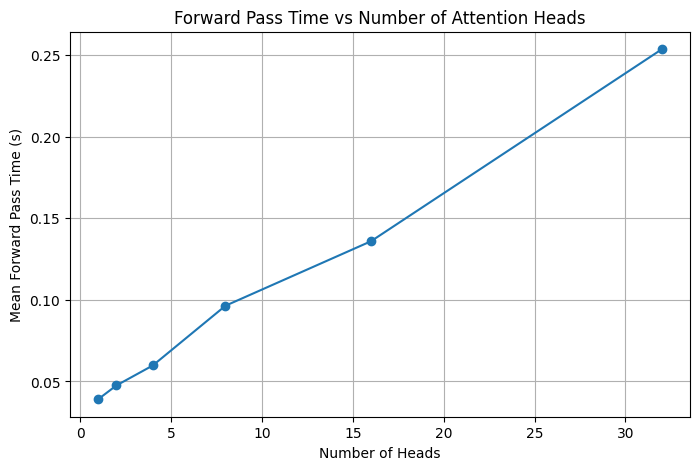

In [39]:
heads = []
fwd_times = []

for h, r in results.items():
    heads.append(h)
    fwd_times.append(r["mean_forward_time"])

plt.figure(figsize=(8, 5))
plt.plot(heads, fwd_times, marker="o")
plt.xlabel("Number of Heads")
plt.ylabel("Mean Forward Pass Time (s)")
plt.title("Forward Pass Time vs Number of Attention Heads")
plt.grid(True)
plt.show()


Plot results, in this case we find that the increase in heads and amount of time that passes for forwarding to be quite linear.

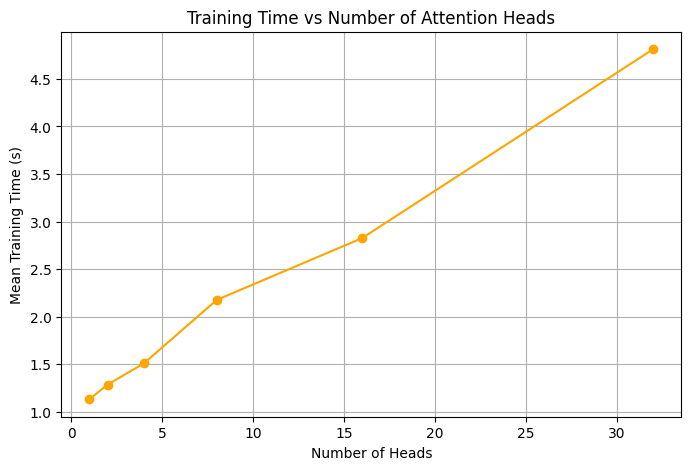

In [40]:
train_times = [results[h]["mean_total_time"] for h in heads]

plt.figure(figsize=(8, 5))
plt.plot(heads, train_times, marker="o", color="orange")
plt.xlabel("Number of Heads")
plt.ylabel("Mean Training Time (s)")
plt.title("Training Time vs Number of Attention Heads")
plt.grid(True)
plt.show()


Generate graph for number of heads vs mean training time which again looks very linear which is a bit surprising. Perhaps this shows the limit of paralelization with improvements being mostly finished in lower overheads. Probably would improve with more GPUs than just what my laptop has.

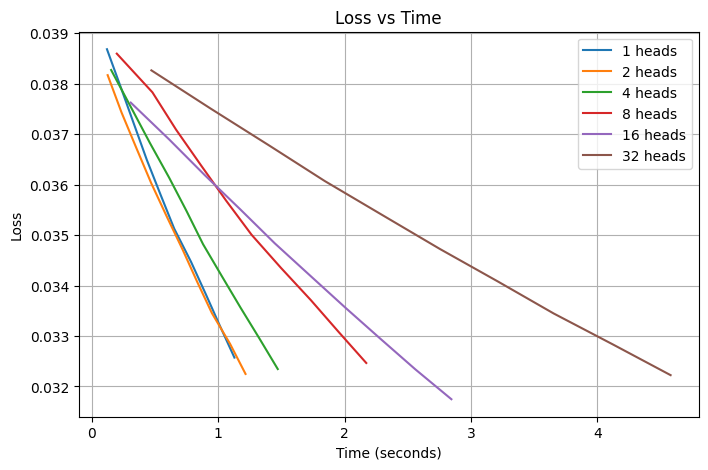

In [41]:
plt.figure(figsize=(8, 5))

for h in heads:
    times, losses = results[h]["loss_curves"][0]  # first run
    plt.plot(times, losses, label=f"{h} heads")

plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.title("Loss vs Time")
plt.legend()
plt.grid(True)
plt.show()


graph loss vs time which results in less loss over time as the number of heads increase which is to be expected.

In [42]:
if device.type == "cuda":
    mems = [results[h]["mean_peak_memory"] for h in heads]

    plt.figure(figsize=(8, 5))
    plt.plot(heads, mems, marker="o", color="green")
    plt.xlabel("Number of Heads")
    plt.ylabel("Peak GPU Memory (MB)")
    plt.title("Peak Memory Usage vs Number of Attention Heads")
    plt.grid(True)
    plt.show()
